# S&P 500 Equity+Options: Risk Controls

This notebook applies predeclared position-level risk rules to the allocation
lineage that ranks first on validation Sharpe among the full-coverage
candidates. It asks whether stop losses, trailing stops, or time exits improve
validation Sharpe and drawdown relative to the same no-overlay baseline. Every
measurement here comes from validation; the 2021 holdout is read in
`18_strategy_analysis`.

**Learning objectives**

1. Carry the highest-ranked full-coverage allocation lineage into a
   controlled risk sweep.
2. Compare fixed stop-loss, trailing-stop, and time-exit rules.
3. Evaluate each overlay with a paired block-bootstrap Sharpe-difference
   interval against its exact no-overlay baseline.
4. Separate validation tuning from evidence of out-of-sample efficacy.

**Book reference:** Chapter 19, Sections 19.3-19.6.

**Prerequisites:** `15_portfolio_management` and the cost diagnostics in
`16_costs`. Signals form after Friday's close and execute at the next
available open, normally Monday. The current-constituent universe retains
survivorship bias. Results describe this retrospective roster during the
development window, not the historical index-membership process or a
prospective S&P 500 population.

In [1]:
"""S&P 500 Equity+Options: position-level risk-control sweep."""

import json
import sqlite3
import time
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

Shared helpers keep strategy construction, execution, registry access, and
paired uncertainty consistent with the preceding pipeline stages.

In [2]:
from case_studies.research import Study
from case_studies.utils.backtest_loaders import (
    VECTORIZED_CASE_STUDIES,
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    strategy_view,
)
from case_studies.utils.backtest_runner import precompute_weights, run_backtest
from case_studies.utils.notebook_contracts import prediction_members_in_force
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    model_source,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_position_risk_controls,
    get_top_n_predictions,
)
from case_studies.utils.uncertainty import (
    compute_paired_uncertainty,
    load_daily_returns_with_timestamp,
    periods_per_year_from_setup,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

In [3]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
LABEL = ""
MAX_SYMBOLS = 0
MAX_RISK_VARIANTS = 0
TOP_N_COMBOS = None

### What is asked for, and what it resolves to

The parameters above are the request; the values this notebook runs on are resolved here under
different names, so a resolved value cannot overwrite the request that produced it. An injected
parameter wins; otherwise the case study's own declaration does.

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_DB = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY_ID)
TOP_N = (
    TOP_N_COMBOS
    if TOP_N_COMBOS is not None
    else get_top_n_predictions(CASE_STUDY_ID, "risk_overlay")
)
RISK_LABEL = LABEL or bt_config.primary_label
if CASE_STUDY_ID in VECTORIZED_CASE_STUDIES:
    raise RuntimeError("This notebook requires engine-level position rules")

print(f"Case study: {CASE_STUDY_ID}; label: {RISK_LABEL}; selected lineages: {TOP_N}; mode: engine")

Case study: sp500_equity_option_analytics; label: fwd_ret_5d; selected lineages: 1; mode: engine


## 1. Advance the highest-ranked eligible strategy carrier

Selection compares the equal-weight baseline with active alternative
allocators using validation Sharpe and maximum prediction coverage.
Historical rows from removed allocators cannot enter the corrected risk stage.

**The carrier is whichever strategy row ranks highest, so the pool it is drawn from decides what
is being overlaid.** A population is immutable and the registry keeps every generation of it, so
a pool built straight from `backtest_runs` counts retired members beside current ones - nothing
in the read path filters on supersession (`case_studies/utils/registry/queries.py` contains no
occurrence of `supersed`). A retired generation that outranks its own replacement would carry the
risk comparison, and the notebook would report an overlay on a strategy the case study no longer
publishes. `prediction_hashes` is passed rather than applied afterwards because it also scopes
the full-coverage bar the query ranks against: a retired row with a longer in-window count would
otherwise set a bar its live replacement cannot meet.

In [5]:
# `Study.at` is the read-only form: one root, no activation. These notebooks only read the
# populations - their backtests reach the registry by their own paths - and every other way in
# ends in `activate()`, which rewrites `ML4T_OUTPUT_DIR` process-wide. `open_study` with the
# canonical tier routes to `Study.regenerate`, which refuses unless `features`, `labels` and
# `run_log` are symlinks: true in a maintainer worktree, false in every clean clone and CI run.
# `CASE_DIR` is already the directory this notebook resolved, including under a preview, so
# asking it directly answers for the registry the rest of the notebook reads.
_study = Study.at(CASE_DIR, case_study=CASE_STUDY_ID, entry_point="17_risk_management")
_members, _population_notes = prediction_members_in_force(_study)
for _note in _population_notes:
    print(_note)
CURRENT_MEMBERS = _members
if CURRENT_MEMBERS is not None:
    print(f"{len(CURRENT_MEMBERS):,} prediction sets in the populations in force")

947 prediction sets in the populations in force


In [6]:
active_allocators = {item["method"] for item in get_allocators(CASE_STUDY_ID)}
baseline_pool = resolve_best_backtest_runs(
    CASE_STUDY_ID,
    RISK_LABEL,
    split="validation",
    stage="signal",
    top_n=9999,
    prediction_hashes=CURRENT_MEMBERS,
)
allocation_pool = resolve_best_backtest_runs(
    CASE_STUDY_ID,
    RISK_LABEL,
    split="validation",
    stage="allocation",
    top_n=9999,
    prediction_hashes=CURRENT_MEMBERS,
)
candidate_pool = pl.concat([baseline_pool, allocation_pool], how="diagonal_relaxed").unique(
    "backtest_hash"
)
candidate_hashes = candidate_pool["prediction_hash"].unique().to_list()
if not candidate_hashes:
    raise RuntimeError("No full-coverage baseline or allocation candidates found")

Resolve model labels from prediction provenance, then filter the strategy
rows against the active allocator configuration.

In [7]:
with sqlite3.connect(REGISTRY_DB) as db:
    source_rows = db.execute(
        f"""
        SELECT p.prediction_hash, t.family, t.config_name
        FROM prediction_sets p
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE p.prediction_hash IN ({",".join("?" for _ in candidate_hashes)})
        """,
        candidate_hashes,
    ).fetchall()
source_by_hash = {
    prediction_hash: model_source(family, config_name)
    for prediction_hash, family, config_name in source_rows
}

eligible_rows = []
for row in candidate_pool.iter_rows(named=True):
    strategy = strategy_view(json.loads(row["spec_json"]))
    allocator = strategy.get("allocation", {}).get("method", "equal_weight")
    if allocator == "equal_weight" or allocator in active_allocators:
        eligible_rows.append(
            {
                **row,
                "source": source_by_hash[row["prediction_hash"]],
                "allocator": allocator,
                "top_k": strategy.get("signal", {}).get("top_k"),
            }
        )

if len(eligible_rows) < TOP_N:
    raise RuntimeError(f"Expected {TOP_N} eligible strategy lineages, found {len(eligible_rows)}")
top_combos = pl.DataFrame(eligible_rows).sort("sharpe", descending=True).head(TOP_N)
carrier = top_combos.row(0, named=True)
print(
    f"Selected {carrier['source']} with {carrier['allocator']} allocation, "
    f"top-{carrier['top_k']}, validation Sharpe {carrier['sharpe']:.3f}"
)

Selected latent_factors/sae with mvo_ledoit_wolf allocation, top-5, validation Sharpe 1.600


The cell above names the lineage this run resolved to. The baseline stays
fixed while the risk rule changes, so every comparison is a paired strategy
perturbation rather than a new model-selection contest.

In [8]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    RISK_LABEL,
    split="validation",
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
print(
    f"Price support: {len(prices):,} rows across {prices['symbol'].n_unique()} historical symbols"
)

Price support: 505,922 rows across 614 historical symbols


## 2. Build the risk-control surface

The sweep uses only the rules declared in `setup.yaml`. A prior version
derived additional MAE thresholds from the full validation price panel and
evaluated them on that same panel. Those tuned-on-validation rules are not
eligible for corrected v3.1 selection.

In [9]:
position_controls = get_position_risk_controls(CASE_STUDY_ID)
if MAX_RISK_VARIANTS > 0:
    position_controls = position_controls[:MAX_RISK_VARIANTS]
if not position_controls:
    raise RuntimeError("No position-level risk controls configured")

base_specs = []
for combo in top_combos.iter_rows(named=True):
    prediction_hash = combo["prediction_hash"]
    base_spec = ensure_backtest_spec(
        CASE_STUDY_ID,
        bt_config,
        json.loads(combo["spec_json"]),
        prices=prices,
        prediction_hash=prediction_hash,
        initial_cash=bt_config.initial_cash,
    )
    base_specs.append((combo, prediction_hash, base_spec))

Each declared rule changes only the position-risk block of its carrier's
strategy specification.

In [10]:
plans = []
for combo, prediction_hash, base_spec in base_specs:
    for control in position_controls:
        spec = clone_backtest_spec(base_spec)
        spec["chapter"] = "ch19"
        rule = {"type": control["type"]}
        if control["type"] == "time_exit":
            rule["bars"] = control["bars"]
        else:
            rule["threshold"] = control["threshold"]
        spec["strategy"]["risk"] = {
            "name": control["name"],
            "position_rules": [rule],
        }
        plans.append(
            {
                "risk_name": control["name"],
                "risk_type": control["type"],
                "source": combo["source"],
                "allocator": combo["allocator"],
                "prediction_hash": prediction_hash,
                "baseline_hash": combo["backtest_hash"],
                "spec": spec,
                "backtest_hash": backtest_hash_from_parts(prediction_hash, spec),
            }
        )

In [11]:
with sqlite3.connect(REGISTRY_DB) as db:
    existing_hashes = {row[0] for row in db.execute("SELECT backtest_hash FROM backtest_runs")}
cached = sum(plan["backtest_hash"] in existing_hashes for plan in plans)
print(f"Planned {len(plans)} risk backtests; {cached} already complete")

Planned 14 risk backtests; 0 already complete


Rules execute inside the event-driven engine on one precomputed allocation
path. Missing rows fail the production run; cached hashes are reused.

A shared weight path isolates the position rule as the only difference among
a carrier's risk variants.

In [12]:
def execute_risk_plans(combo: dict, combo_plans: list[dict]) -> list[str]:
    combo_failures = []
    predictions = read_predictions(CASE_STUDY_ID, combo["prediction_hash"])
    weights = precompute_weights(
        predictions,
        combo_plans[0]["spec"],
        prices,
        label=RISK_LABEL,
        case_study=CASE_STUDY_ID,
        prediction_hash=combo["prediction_hash"],
    )
    for index, plan in enumerate(combo_plans, start=1):
        try:
            result = run_backtest(
                CASE_STUDY_ID,
                combo["prediction_hash"],
                plan["spec"],
                prices=prices,
                predictions=predictions,
                label=RISK_LABEL,
                register=True,
                initial_cash=bt_config.initial_cash,
                calendar=bt_config.calendar,
                precomputed_weights=weights,
            )
            existing_hashes.add(plan["backtest_hash"])
            print(
                f"[{index}/{len(combo_plans)}] {plan['risk_name']}: "
                f"Sharpe={result.metrics['sharpe']:.3f}; "
                f"max drawdown={result.metrics['max_drawdown']:.1%}",
                flush=True,
            )
        except Exception as exc:  # noqa: BLE001
            combo_failures.append(f"{plan['backtest_hash']} {plan['risk_name']}: {exc}")
    return combo_failures

In [13]:
failures = []
started = time.monotonic()
for combo in top_combos.iter_rows(named=True):
    combo_plans = [
        plan
        for plan in plans
        if plan["prediction_hash"] == combo["prediction_hash"]
        and plan["backtest_hash"] not in existing_hashes
    ]
    if combo_plans:
        failures.extend(execute_risk_plans(combo, combo_plans))

[1/14] stop_loss_3pct: Sharpe=1.647; max drawdown=-24.2%


[2/14] stop_loss_5pct: Sharpe=1.861; max drawdown=-30.0%


[3/14] stop_loss_10pct: Sharpe=1.718; max drawdown=-39.2%


[4/14] stop_loss_15pct: Sharpe=1.511; max drawdown=-44.9%


[5/14] trailing_1pct: Sharpe=1.694; max drawdown=-10.2%


...

[10/14] trailing_15pct: Sharpe=1.511; max drawdown=-44.9%


[11/14] trailing_20pct: Sharpe=1.508; max drawdown=-48.1%


[12/14] time_exit_10: Sharpe=1.523; max drawdown=-47.0%


[13/14] time_exit_20: Sharpe=1.600; max drawdown=-47.0%


[14/14] time_exit_40: Sharpe=1.600; max drawdown=-47.0%


In [14]:
if failures:
    raise RuntimeError("Risk-sweep failures:\n" + "\n".join(failures))
print(f"Risk surface complete in {(time.monotonic() - started):.1f}s")

Risk surface complete in 15.9s


## 3. Measure paired overlay effects

The registry query is keyed by the hashes planned above. Each overlay's
return series is aligned by timestamp with its exact allocation baseline,
then the same stationary-bootstrap indices are applied to both paths.

In [15]:
plan_meta = pl.DataFrame(
    [
        {
            "backtest_hash": plan["backtest_hash"],
            "baseline_hash": plan["baseline_hash"],
            "risk_name": plan["risk_name"],
            "risk_type": plan["risk_type"],
            "source": plan["source"],
            "allocator": plan["allocator"],
        }
        for plan in plans
    ]
)
placeholders = ",".join("?" for _ in plans)
with sqlite3.connect(REGISTRY_DB) as db:
    metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.stage, bm.sharpe, bm.max_drawdown, bm.num_trades
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({placeholders})
        """,
        connection=db,
        execute_options={"parameters": [plan["backtest_hash"] for plan in plans]},
    )

risk_results = plan_meta.join(metrics, on="backtest_hash", how="inner")
if len(risk_results) != len(plans):
    raise RuntimeError(f"Expected {len(plans)} risk rows, found {len(risk_results)}")
if risk_results.filter(pl.col("stage") != "risk_overlay").height:
    raise RuntimeError("A planned risk hash was registered under the wrong stage")

A paired comparison aligns each overlay with its exact no-overlay carrier,
drops their shared inactive prefix, and resamples both paths together.

In [16]:
def paired_overlay_metrics(row: dict) -> dict:
    baseline = load_daily_returns_with_timestamp(CASE_STUDY_ID, row["baseline_hash"])
    challenger = load_daily_returns_with_timestamp(CASE_STUDY_ID, row["backtest_hash"])
    if baseline is None or challenger is None:
        raise RuntimeError(f"Missing daily returns for {row['risk_name']}")
    aligned = (
        baseline.rename({"ret": "baseline_ret"})
        .join(challenger.rename({"ret": "challenger_ret"}), on="timestamp", how="inner")
        .sort("timestamp")
    )
    if aligned.is_empty():
        raise RuntimeError(f"Degenerate return pair for {row['risk_name']}")
    # The leading inactive sessions are dropped inside `compute_paired_uncertainty`, over both
    # series at once. Trimming per series is what broke this cell: an overlay sits out sessions
    # its carrier trades, so the two sides arrived at different lengths and the paired bootstrap
    # refused every one of them.
    #
    # `challenger_overlays_baseline` says which pair this is, and here it is an overlay running
    # on top of its carrier: both are live from the carrier's first traded session, so a session
    # the overlay sits out is a position it chose to hold and stays in. It is the effect being
    # measured. The default would drop those rows, which is right for a strategy that has a
    # warmup before its first signal and wrong for every rule below.
    paired = compute_paired_uncertainty(
        aligned["challenger_ret"],
        aligned["baseline_ret"],
        periods_per_year=periods_per_year_from_setup(CASE_STUDY_ID),
        case_study=CASE_STUDY_ID,
        label=RISK_LABEL,
        n_boot=2000,
        seed=42,
        challenger_overlays_baseline=True,
    )
    if not paired:
        raise RuntimeError(
            f"Paired uncertainty failed for {row['risk_name']}: the overlay and its carrier "
            f"share {aligned.height} sessions, and too few of them fall after the first one "
            "either side traded. A bootstrap needs at least four."
        )
    return {
        "backtest_hash": row["backtest_hash"],
        "sharpe_diff": paired["sharpe_diff"],
        "sharpe_diff_ci_lo": paired["sharpe_diff_ci95_lo"],
        "sharpe_diff_ci_hi": paired["sharpe_diff_ci95_hi"],
        "prob_overlay_wins": paired["prob_challenger_wins"],
    }

In [17]:
paired_rows = [paired_overlay_metrics(row) for row in risk_results.iter_rows(named=True)]

risk_results = risk_results.join(pl.DataFrame(paired_rows), on="backtest_hash").sort(
    "sharpe", descending=True
)

The chart below ranks every overlay by its paired Sharpe difference against
its own no-overlay carrier. What separates an overlay worth carrying forward
from one that is not is whether its bootstrap interval clears zero, not the
size of the point difference. With every declared rule scored on a single
validation path, a large point difference whose interval spans zero is what
selection noise looks like.

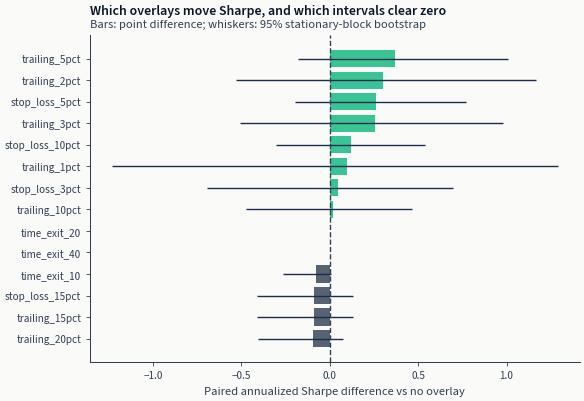

In [18]:
plot_risk = risk_results.sort("sharpe_diff")
fig_delta, ax_delta = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)

points = plot_risk["sharpe_diff"].to_list()
lo = plot_risk["sharpe_diff_ci_lo"].to_list()
hi = plot_risk["sharpe_diff_ci_hi"].to_list()
colors = [COLORS["positive"] if point > 0 else COLORS["neutral"] for point in points]
y = list(range(len(plot_risk)))
ax_delta.barh(y, points, color=colors, alpha=0.82)
ax_delta.errorbar(
    points,
    y,
    xerr=[
        [point - lower for point, lower in zip(points, lo, strict=True)],
        [upper - point for point, upper in zip(points, hi, strict=True)],
    ],
    fmt="none",
    ecolor=COLORS["slate"],
    capsize=2,
    linewidth=1,
)
ax_delta.axvline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax_delta.set_yticks(y, plot_risk["risk_name"].to_list(), fontsize=8)
ax_delta.set_xlabel("Paired annualized Sharpe difference vs no overlay")
add_message_title(
    ax_delta,
    "Which overlays move Sharpe, and which intervals clear zero",
    "Bars: point difference; whiskers: 95% stationary-block bootstrap",
)
fig_delta.show()

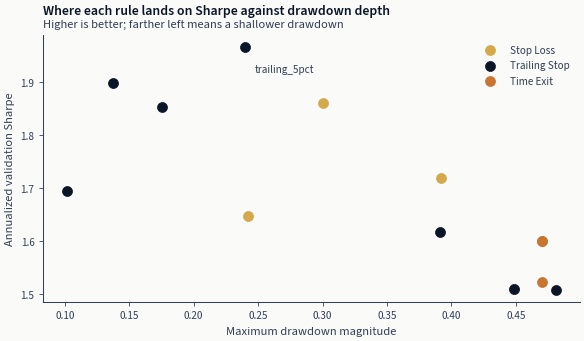

In [19]:
fig_tradeoff, ax_tradeoff = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
type_colors = {
    "stop_loss": COLORS["amber"],
    "trailing_stop": COLORS["blue"],
    "time_exit": COLORS["copper"],
}
for risk_type, color in type_colors.items():
    subset = risk_results.filter(pl.col("risk_type") == risk_type)
    ax_tradeoff.scatter(
        -subset["max_drawdown"],
        subset["sharpe"],
        s=52,
        color=color,
        label=risk_type.replace("_", " ").title(),
    )
top_overlay = risk_results.row(0, named=True)
ax_tradeoff.annotate(
    top_overlay["risk_name"],
    (-top_overlay["max_drawdown"], top_overlay["sharpe"]),
    xytext=(7, -12),
    textcoords="offset points",
    fontsize=8,
    va="top",
)
ax_tradeoff.set_xlabel("Maximum drawdown magnitude")
ax_tradeoff.set_ylabel("Annualized validation Sharpe")
ax_tradeoff.legend(frameon=False)
add_message_title(
    ax_tradeoff,
    "Where each rule lands on Sharpe against drawdown depth",
    "Higher is better; farther left means a shallower drawdown",
)

fig_tradeoff.show()

## Key takeaways

1. Risk selection is validation-only. It carries the eligible lineage that
   ranks first on validation Sharpe forward without consulting the holdout.
2. Every overlay is scored against its own carrier's no-overlay path, so the
   position rule is the only difference inside a pair.
3. An overlay earns a claim only where its paired bootstrap interval excludes
   zero. The ordering of point differences on its own establishes nothing.
4. Full-validation MAE-calibrated thresholds are excluded from corrected
   v3.1 because their thresholds were learned from the same validation paths
   used to score them.
5. The predeclared overlays still constitute a selection cohort. The holdout
   can be used once on the final carrier, not to choose among them.

**Next:** `18_strategy_analysis` locks the corrected validation carrier and
compares it with the preserved historical holdout without reading that window
a second time on the new lineage. See Chapter 20 for the strategy synthesis framework.